# Gated Recurrent Network Example

This notebook contains an example of training and evaluating a GRU using battery lifetime data

## Battery Life Dataset

The example uses the NASA battery life dataset.  You can download a version in CSV format from Kaggle here :
https://www.kaggle.com/datasets/patrickfleith/nasa-battery-dataset/data

Just unzip the downloaded file into the same folder as this notebook.

The data comprises a file containing time series data for each charge or discharge cycle, as well as impedance measurements made between cycles, and a file of metadata.

First we inspect the metadata file.  Note that this states the battery capacity at the start of each discharge cycle.

In [22]:
import pandas as pd

# read the metadata file
metadata_df = pd.read_csv("cleaned_dataset/metadata.csv")
metadata_df



{'B0043', 'B0048', 'B0039', 'B0040', 'B0052', 'B0007', 'B0006', 'B0041', 'B0047', 'B0005', 'B0034', 'B0051', 'B0049', 'B0029', 'B0053', 'B0046', 'B0030', 'B0026', 'B0044', 'B0056', 'B0018', 'B0050', 'B0025', 'B0033', 'B0036', 'B0054', 'B0055', 'B0031', 'B0028', 'B0027', 'B0042', 'B0045', 'B0032', 'B0038'}
34


Next we can open and plot the contents of a few charge/discharge files.

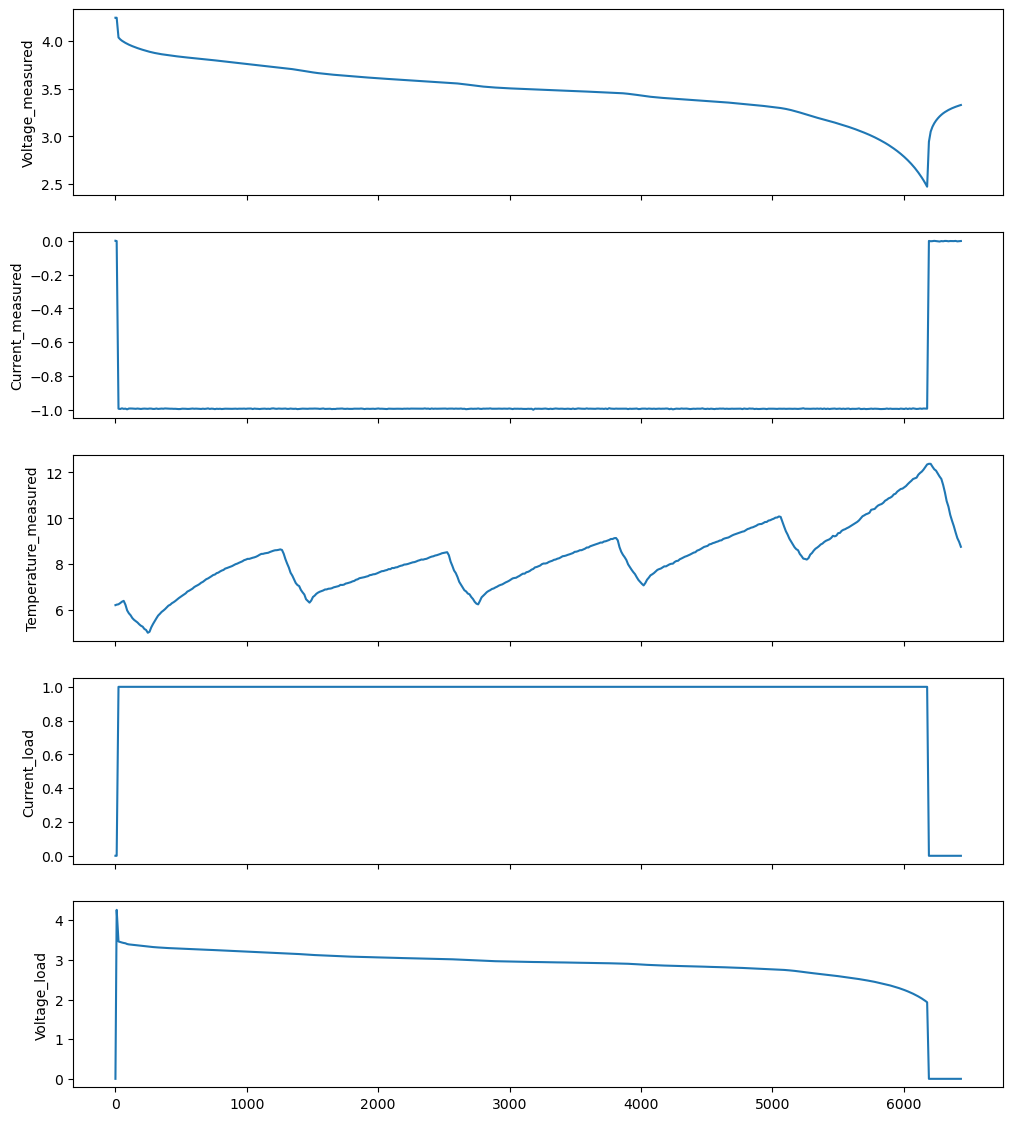

In [35]:
import matplotlib.pyplot as plt

# read and plot a discharge file
data_df = pd.read_csv("cleaned_dataset/data/00001.csv")

fig, axs = plt.subplots(5, sharex=True)
fig.set_figwidth(12)
fig.set_figheight(14)

for i,col in enumerate(data_df.columns):
    if i==5:
        break
    axs[i].plot(data_df["Time"], data_df[col])
    axs[i].set_ylabel(col)

fig.savefig("discharge.pdf")

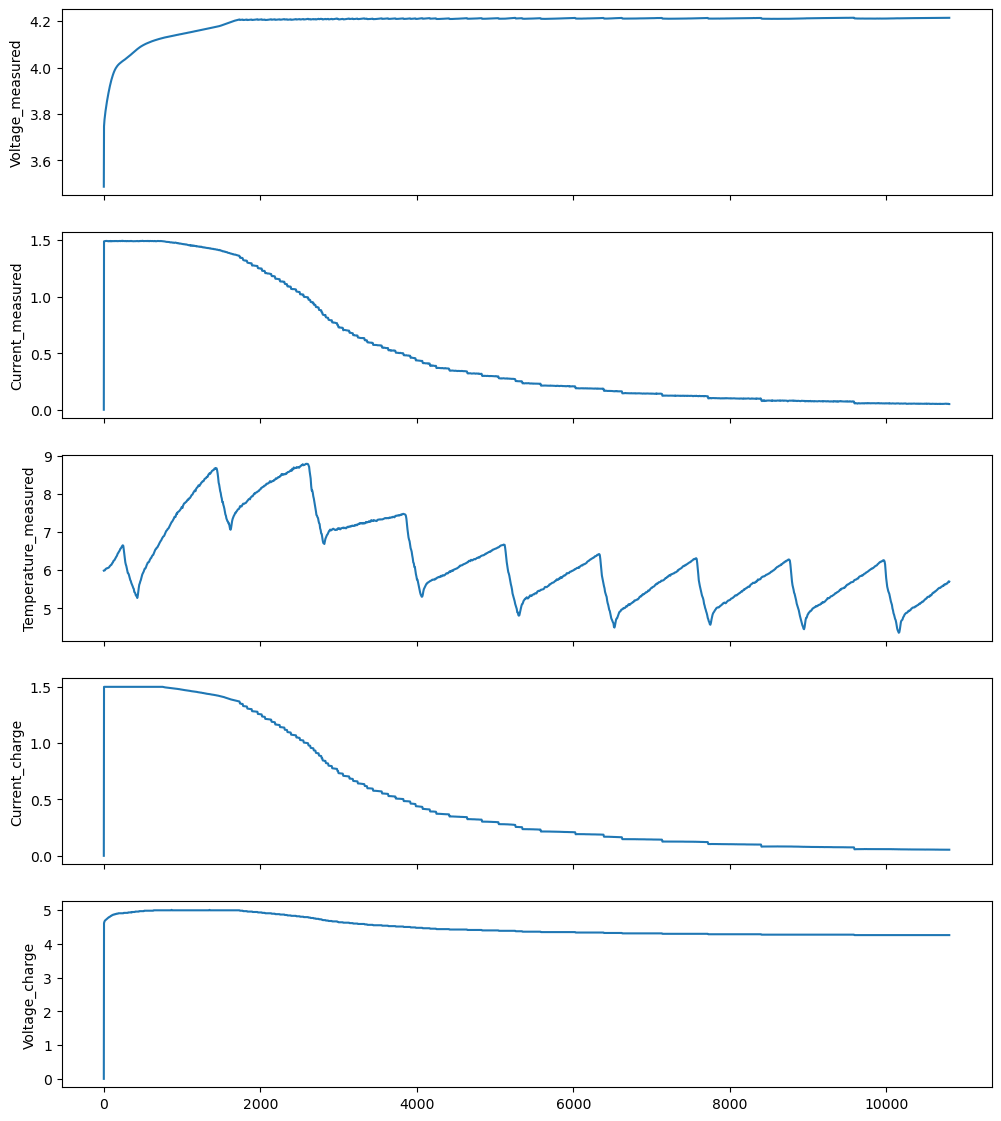

In [36]:
# read and plot a charge file
data_df = pd.read_csv("cleaned_dataset/data/00003.csv")

fig, axs = plt.subplots(5, sharex=True)
fig.set_figwidth(12)
fig.set_figheight(14)

for i,col in enumerate(data_df.columns):
    if i==5:
        break
    axs[i].plot(data_df["Time"], data_df[col])
    axs[i].set_ylabel(col)

fig.savefig("charge.pdf")

In [2]:
# now implement a GRU
import torch.nn as nn
import torch.nn.functional as F

class SimpleGRU(nn.Module):
    
    def __init__(self):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc1 = nn.Linear(hidden_size * sequence_length, num_classes)
    
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        
        out,_ = self.gru(x, h0)
        out = out.reshape(out.shape[0], -1)
        out = self.fc1(out)
        return out


TypeError: RNNBase.__init__() missing 2 required positional arguments: 'input_size' and 'hidden_size'